Read historical data from solcast to train baseline data. then use solcast current data and predict baseline to analyse.

In [31]:
import pandas as pd
import numpy as np
import pyodbc
import matplotlib.pyplot as plt
import seaborn as sns
import urllib
import warnings
import joblib
import os

warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sqlalchemy import create_engine

In [32]:
def compute_diff(series):
    series_diff = series.diff()
    return series_diff

def handle_outliers(series):
    threshold = np.nanquantile(series, 0.999)
    return series.where((series <= threshold) & (series >= 0), np.nan)

def adjust_year(x, target_year=2021):
    try:
        return x.replace(year=target_year)
    except ValueError:  # February 29th does not exist in a non-leap year
        return x.replace(year=target_year, day=28)

In [33]:
# Database details
server = '23.101.237.42'
database = 'leap'
username = 'sa'
password = 'NjOzAi^GpU!!'

# Create the connection URL for the SQLAlchemy engine
# Note: We use urllib.parse.quote_plus to ensure special characters in the password (or username) are correctly formatted
connection_url = f"mssql+pyodbc:///?odbc_connect=" + urllib.parse.quote_plus(
    f"DRIVER={{ODBC Driver 18 for SQL Server}};SERVER={server};DATABASE={database};UID={username};PWD={password};TrustServerCertificate=yes"
)

solcast historical data as for the baseline.
 solsite simulation db have solar company data


Load Historical data to learn models for each meter.

In [34]:
bun_sol_df = pd.read_csv('data/bundoora_solcast.csv')
bun_sol_df['campus'] = ['BUNDOORA'] * len(bun_sol_df)

wod_sol_df = pd.read_csv('data/wodonga_solcast.csv')
wod_sol_df['campus'] = ['WODONGA'] * len(bun_sol_df)

ben_sol_df = pd.read_csv('data/bendigo_solcast.csv')
ben_sol_df['campus'] = ['BENDIGO'] * len(bun_sol_df)

mil_sol_df = pd.read_csv('data/mildura_solcast.csv')
mil_sol_df['campus'] = ['MILDURA'] * len(bun_sol_df)

she_sol_df = pd.read_csv('data/shepparton_solcast.csv')
she_sol_df['campus'] = ['SHEPPARTON'] * len(bun_sol_df)

solcast_hist_df = pd.concat([bun_sol_df, wod_sol_df, ben_sol_df, mil_sol_df, she_sol_df])
solcast_hist_df['timestamp'] = pd.to_datetime(solcast_hist_df['period_end']).dt.strftime('%Y-%m-%d %H:%M:%S')
solcast_hist_df['timestamp'] = pd.to_datetime(solcast_hist_df['timestamp'])
solcast_hist_df.drop(columns=['clearsky_dhi', 'clearsky_dni', 'clearsky_ghi', 'period', 'period_end'], inplace=True)


Load new data that are not included in above files.

In [35]:
from azure.storage.blob import BlobServiceClient
from io import StringIO

sas_token = "UmQIm94uLMGZkl8vOie0B1omByZBzJmP6tNodMe9HVHlgWAgprw2OX62wXCZqmJ4jAH04IBlfM5xNukhc3x9rQ=="
container_name = "solar-forecasts-solcast"

blob_service_client = BlobServiceClient(account_url="https://leapdata.blob.core.windows.net", credential=sas_token)
container_client = blob_service_client.get_container_client(container_name)

csv_files = [blob.name for blob in container_client.list_blobs() if "live" in blob.name and blob.name.endswith(".csv")]

dataframes = []
for file in csv_files:
    blob_client = container_client.get_blob_client(file)
    csv_data = blob_client.download_blob().content_as_text()
    temp_df = pd.read_csv(StringIO(csv_data))
    temp_df['source_file'] = file  # Add source file column to track file origins
    dataframes.append(temp_df)

solcast_live_df = pd.concat(dataframes)
solcast_live_df['accessed_on'] = pd.to_datetime(solcast_live_df['accessed_on'])
solcast_live_df['timestamp'] = pd.to_datetime(solcast_live_df['timestamp'])
solcast_live_df = solcast_live_df.sort_values(by='accessed_on').drop_duplicates(subset=['timestamp', 'campus'], keep='last')
# solcast_live_df = solcast_live_df.sort_values(by='timestamp')
solcast_live_df = solcast_live_df[solcast_live_df['timestamp'] > '2023-01-13 00:00:00']   # university wise .csv files have only data until july 13
solcast_live_df = solcast_live_df.sort_values(by='timestamp')
solcast_live_df.drop(columns=['accessed_on', 'source_file', 'timestamp_utc'], inplace=True)



In [36]:
solcast_live_df
solcast_df = pd.concat([solcast_hist_df, solcast_live_df])


solcast_df.to_csv("data/solcast_real.csv")

solcast_forecast_df = solcast_df[solcast_df['timestamp'] > '2025-01-01 00:00:00'] 

In [37]:
pd.unique(solcast_forecast_df['campus'])

array(['BUNDOORA', 'MILDURA', 'SHEPPARTON', 'BENDIGO', 'WODONGA'],
      dtype=object)

Merge hist data and live data into one file

In [38]:
solcast_forecast_df    # weather data of all the area by each 30 minutes, from 2021 to present
# solcast_live_df.to_csv('data/model_accuracy.csv', index=False)
solcast_forecast_df.to_csv("data/solcast_pred.csv")

Get All meter names

In [39]:

meters = ["solar.bun_cs1#realenergyintotheload#kwh", "solar.ben_carpark#realenergyintotheload#kwh"]#, "solar.bun_hv_incoming#realenergyintotheload#kwh"]

In [41]:
# meters = list(set(meters_df['meter']))

campuses = []
for meter in meters:
    if('bun' in meter): campuses.append('BUNDOORA')
    elif('albury' in meter): campuses.append('WODONGA')
    elif('bendigo' in meter): campuses.append('BENDIGO')
    elif('ben' in meter): campuses.append('BENDIGO')
    elif('mildura' in meter): campuses.append('MILDURA')
    elif('shepparton' in meter): campuses.append('SHEPPARTON')
    elif('shepparton' in meter): campuses.append('SHEPPARTON')

print(campuses)

['BUNDOORA', 'BENDIGO']


Read power generation data from Solar site simulator table. Then train models for weather data and power generation.

In [42]:
acc_df = pd.read_csv('data/model_accuracy.csv')

## Training XGBoost models   -  Simulated model

## Load Real 1 hour data

In [12]:
old_final_df = pd.read_csv("data/SolarMeterReadings1hour.csv")
last_date = list(old_final_df['timestamp'])[-1]

print(last_date)

2025-11-18 02:00:00


In [13]:
# meters = meters[:1]
print(meters)

['solar.bun_cs1#realenergyintotheload#kwh', 'solar.ben_carpark#realenergyintotheload#kwh']


## Load Meter readings from database

In [43]:
engine = create_engine(connection_url)

dfs = []  
for meter in meters:
    print(f"Processing {meter}")
    
    try:
        # query = f"SELECT * FROM [SolarMeterReadings] WHERE [MeterKeyString] = '{meter}' AND [ReadingTimestamp] > '{last_date}'  ORDER BY ReadingTimestamp"
        query = f"SELECT * FROM [SolarMeterReadings] WHERE [MeterKeyString] = '{meter}'  ORDER BY ReadingTimestamp"
        df = pd.read_sql_query(query, engine)
        df.drop_duplicates(subset=['ReadingTimestamp'], inplace=True)
        df['MeterReading'] = df['MeterReading'].interpolate()
        df['Difference'] = df['MeterReading'].transform(compute_diff)
        df['meter_reading'] = df['Difference'].transform(handle_outliers)
        df['meter_reading'].interpolate(method='linear', inplace=True)
        # df['data_out'] = np.where(df['meter_reading'].isnull(), 1, 0)
        df['timestamp'] = pd.to_datetime(df['ReadingTimestamp'])

        df.set_index('timestamp', inplace=True)
        df = df.resample('1H').agg({'meter_reading': 'sum'})
        df.reset_index(inplace=True)
        
        df['meter'] = [meter] * len(df)
        dfs.append(df)
    except:
        print(f"{meter} failed")
# Close the engine connection

final_df = pd.concat(dfs)
final_df = pd.concat([old_final_df, final_df])
final_df.to_csv('data/SolarMeterReadings1hour.csv', index=False)
engine.dispose()

Processing solar.bun_cs1#realenergyintotheload#kwh
Processing solar.ben_carpark#realenergyintotheload#kwh


## Train Reasl XGBoost models - preprocess

In [49]:
final_df = pd.read_csv("data/3main_meter_combined_hourly.csv")
print(list(pd.unique(final_df["meter"])))

['solar.bun_LTSS_PV_LGC#realenergyintotheload#kwh', 'solar.bun_hv_incoming#realenergyintotheload#kwh', 'solar.ben_carpark#realenergyintotheload#kwh']


In [50]:
def get_campus(meter_name: str) -> str:
    name = meter_name.lower()
    if "bun" in name:
        return "BUNDOORA"
    elif "albury" in name:
        return "WODONGA"
    elif "bendigo" in name:
        return "BENDIGO"
    elif "ben" in name:
        return "BENDIGO"
    elif "mildura" in name:
        return "MILDURA"
    elif "shepparton" in name:
        return "SHEPPARTON"
    else:
        return "UNKNOWN"


final_df["campus"] = final_df["meter"].apply(get_campus)

# print(final_df.iloc[500000])

solcast_df['global_horizontal_irradiance'] = solcast_df['ghi']
solcast_forecast_df['global_horizontal_irradiance'] = solcast_forecast_df['ghi']
final_df['grid_power_kWh'] = final_df['meter_reading']
# final_df["timestamp"]     = pd.to_datetime(final_df["timestamp"], errors="coerce", utc=True)\
#                              .dt.tz_convert("UTC").dt.tz_localize(None)
# solcast_df["timestamp"] = pd.to_datetime(solcast_df["timestamp"], errors="coerce", utc=True)\
#                              .dt.tz_convert("UTC").dt.tz_localize(None)


final_df['timestamp'] = pd.to_datetime(final_df['timestamp'], format="%d/%m/%Y %H:%M", )

solcast_df['timestamp'] = pd.to_datetime(solcast_df['timestamp'])

            timestamp  meter_reading  \
0 2023-11-01 00:00:00          0.000   
1 2023-11-01 01:00:00          0.000   
2 2023-11-01 02:00:00          0.000   
3 2023-11-01 03:00:00          0.000   
4 2023-11-01 04:00:00          0.000   
5 2023-11-01 05:00:00          0.000   
6 2023-11-01 06:00:00          0.625   
7 2023-11-01 07:00:00          8.250   
8 2023-11-01 08:00:00         34.250   
9 2023-11-01 09:00:00         65.000   

                                             meter    campus  grid_power_kWh  
0  solar.bun_LTSS_PV_LGC#realenergyintotheload#kwh  BUNDOORA           0.000  
1  solar.bun_LTSS_PV_LGC#realenergyintotheload#kwh  BUNDOORA           0.000  
2  solar.bun_LTSS_PV_LGC#realenergyintotheload#kwh  BUNDOORA           0.000  
3  solar.bun_LTSS_PV_LGC#realenergyintotheload#kwh  BUNDOORA           0.000  
4  solar.bun_LTSS_PV_LGC#realenergyintotheload#kwh  BUNDOORA           0.000  
5  solar.bun_LTSS_PV_LGC#realenergyintotheload#kwh  BUNDOORA           0.000  
6  sol

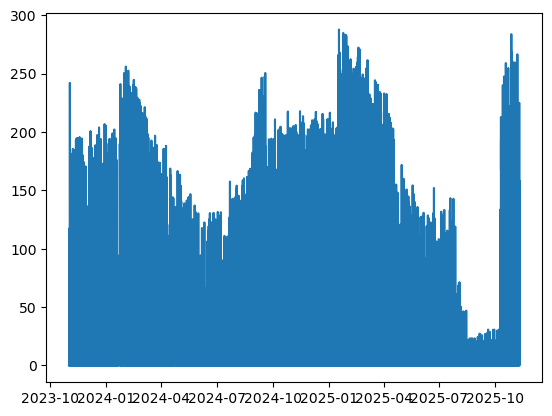

In [51]:
df__ = final_df[final_df["meter"] == "solar.bun_LTSS_PV_LGC#realenergyintotheload#kwh"]
print(final_df.head(10))
plt.plot(df__["timestamp"], df__["grid_power_kWh"])
plt.show()

In [52]:
meters = list(pd.unique(final_df["meter"]))
# campuses = list(pd.unique(final_df["campus"]))
# meters = ['solar.bun_bg#realenergyintotheload#kwh']
print(meters)
print(final_df.keys())
# meters = ['solar.bun_LTSS_PV_LGC#realenergyintotheload#kwh','solar.bun_hv_incoming#realenergyintotheload#kwh','solar.ben_carpark#realenergyintotheload#kwh']

['solar.bun_LTSS_PV_LGC#realenergyintotheload#kwh', 'solar.bun_hv_incoming#realenergyintotheload#kwh', 'solar.ben_carpark#realenergyintotheload#kwh']
Index(['timestamp', 'meter_reading', 'meter', 'campus', 'grid_power_kWh'], dtype='object')


## Filter proper days for training

In [18]:
import pandas as pd
import numpy as np
'''
def make_xgb_training_perfect_days(
    df,
    ts_col="timestamp",
    meter_col="meter",
    value_col="grid_power_kWh",
    night_hours=(0,1,2,3,4,5,21,22,23),
    min_day_active_hours=6,
    night_rel=0.02,
    night_abs=0.05,
    day_rel=0.05,
    day_abs=0.10,
    spike_mult=3.0,
    require_exact_full_day=True,
    coverage_tolerance=0.8,     # allow >=80% of expected samples
):
    if df.empty:
        return df

    out = df.copy()
    out[ts_col] = pd.to_datetime(out[ts_col], errors="coerce")
    out = out.dropna(subset=[ts_col]).sort_values(ts_col)

    # Remove accidental index column if present
    if "Unnamed: 0" in out.columns:
        out = out.drop(columns=["Unnamed: 0"])

    # DEDUPLICATE after merges (critical)
    out = out.drop_duplicates(subset=[ts_col])

    # numeric value
    out[value_col] = pd.to_numeric(out[value_col], errors="coerce")

    # Detect cadence robustly: use positive deltas only
    dt = out[ts_col].diff().dt.total_seconds().dropna()
    dt = dt[dt > 0] / 60.0  # minutes
    if dt.empty:
        freq_min = 60
    else:
        dt_rounded = dt.round().astype(int)
        # prefer mode; if multi-modal, fallback to median
        if dt_rounded.mode().empty:
            freq_min = int(np.median(dt_rounded))
        else:
            freq_min = int(dt_rounded.mode().iloc[0])
        if freq_min <= 0:
            freq_min = 60

    expected_per_day = int(round(24 * 60 / freq_min))
    min_required_per_day = int(np.floor(expected_per_day * coverage_tolerance))

    out["__date"] = out[ts_col].dt.date
    out["__hour"] = out[ts_col].dt.hour

    # Robust thresholds (percentile-based) + cadence scaling for energy-per-interval
    pos = out.loc[out[value_col] > 0, value_col]
    p95 = float(pos.quantile(0.95)) if len(pos) else 0.0
    p99 = float(pos.quantile(0.99)) if len(pos) else 0.0

    scale = max(freq_min / 60.0, 1e-6)  # 30 min -> 0.5, 15 min -> 0.25
    night_thresh = max(night_abs * scale, night_rel * p95)
    day_thresh   = max(day_abs   * scale, day_rel   * p95)
    spike_cap    = (p99 * spike_mult) if p99 > 0 else float("inf")

    def is_perfect_day(g):
        v = g[value_col].values
        h = g["__hour"].values

        # coverage with tolerance or strict
        if require_exact_full_day:
            if len(g) < min_required_per_day:
                return False

        # No NaNs/negatives
        if np.isnan(v).any() or (v < 0).any():
            return False

        # Night quiet
        night_vals = v[np.isin(h, night_hours)]
        if night_vals.size and not np.all(night_vals <= night_thresh):
            return False

        # Day activity: count per-hour maxima above threshold
        day_mask = ~np.isin(h, night_hours)
        if not day_mask.any():
            return False
        g2 = pd.DataFrame({"hour": h[day_mask], "val": v[day_mask]})
        active_hours = g2.groupby("hour")["val"].max() > day_thresh
        if active_hours.sum() < min_day_active_hours:
            return False

        # No extreme spikes
        if np.nanmax(v) > spike_cap:
            return False

        return True

    flags = out.groupby("__date", sort=False).apply(is_perfect_day).rename("ok").reset_index()
    keep_dates = set(flags.loc[flags["ok"], "__date"])

    filtered = out[out["__date"].isin(keep_dates)].drop(columns=["__date","__hour"])
    return filtered


def uniq_weather(df_weather, ts_col="timestamp"):
    w = df_weather.copy()
    w[ts_col] = pd.to_datetime(w[ts_col], errors="coerce")
    w = w.dropna(subset=[ts_col]).sort_values(ts_col)
    # Pick one row per timestamp (or change to groupby().mean() if you truly have multiples)
    w = w.drop_duplicates(subset=[ts_col], keep="first")
    return w

def enforce_unique_timestamps(df, ts_col="timestamp"):
    d = df.copy()
    d[ts_col] = pd.to_datetime(d[ts_col], errors="coerce")
    d = d.dropna(subset=[ts_col]).sort_values(ts_col)
    # remove duplicated timestamps created by one-to-many merges
    d = d.drop_duplicates(subset=[ts_col], keep="first")
    return d'''

import pandas as pd
import numpy as np

def make_xgb_training_perfect_days(
    df,
    ts_col="timestamp",
    meter_col="meter",
    value_col="grid_power_kWh",
    night_hours=(0,1,2,3,4,5,21,22,23),
    min_day_active_hours=6,
    night_rel=0.02,
    night_abs=0.05,
    day_rel=0.05,
    day_abs=0.10,
    spike_mult=3.0,
    require_exact_full_day=False,   # <- softened
    coverage_tolerance=0.7,         # <- softened
):
    if df.empty:
        return df

    out = df.copy()
    out[ts_col] = pd.to_datetime(out[ts_col], errors="coerce")
    out = out.dropna(subset=[ts_col]).sort_values(ts_col)

    # Remove accidental index column if present
    if "Unnamed: 0" in out.columns:
        out = out.drop(columns=["Unnamed: 0"])

    # --- IMPORTANT: keep one row per (timestamp, meter)
    if meter_col in out.columns:
        out = out.drop_duplicates(subset=[ts_col, meter_col])
    else:
        out = out.drop_duplicates(subset=[ts_col])

    # numeric value
    out[value_col] = pd.to_numeric(out[value_col], errors="coerce")

    # Derived cols
    out["__date"] = out[ts_col].dt.date
    out["__hour"] = out[ts_col].dt.hour

    # Helper: compute thresholds per meter from its own distribution
    def meter_thresholds(g):
        pos = g.loc[g[value_col] > 0, value_col]
        p95 = float(pos.quantile(0.95)) if len(pos) else 0.0
        p99 = float(pos.quantile(0.99)) if len(pos) else 0.0
        return p95, p99

    keep_index = []

    # Group by meter first (or a single group if meter_col missing)
    meter_groups = [ (None, out) ] if meter_col not in out.columns else out.groupby(meter_col, sort=False)

    for m_key, g_meter in meter_groups:
        # Per-meter cadence/coverage: use median count per day (robust to DST/irregular)
        per_day_counts = g_meter.groupby(g_meter[ts_col].dt.date).size()
        if per_day_counts.empty:
            continue
        expected_per_day = int(per_day_counts.median())  # robust baseline
        min_required = int(np.floor(expected_per_day * coverage_tolerance)) if expected_per_day > 0 else 1

        p95, p99 = meter_thresholds(g_meter)
        night_thresh = max(night_abs, night_rel * p95)
        day_thresh   = max(day_abs,  day_rel  * p95)
        spike_cap    = (p99 * spike_mult) if p99 > 0 else float("inf")

        def day_ok(g_day):
            v = g_day[value_col].to_numpy(dtype=float)
            h = g_day["__hour"].to_numpy(dtype=int)

            # coverage
            if require_exact_full_day:
                if len(g_day) < min_required:
                    return False
            else:
                # allow partial days but reject extremely sparse ones (<30% of expected)
                if expected_per_day > 0 and len(g_day) < max(1, int(0.3 * expected_per_day)):
                    return False

            # NaNs/negatives
            if np.isnan(v).any() or (v < 0).any():
                return False

            # Night quiet (tolerant)
            night_vals = v[np.isin(h, night_hours)]
            if night_vals.size and np.nanmax(night_vals) > night_thresh:
                # allow one-off tiny leak by using 95th percentile
                if np.nanpercentile(night_vals, 95) > night_thresh:
                    return False

            # Day activity
            day_mask = ~np.isin(h, night_hours)
            if not day_mask.any():
                return False
            g2 = pd.DataFrame({"hour": h[day_mask], "val": v[day_mask]})
            active_hours = (g2.groupby("hour")["val"].max() > day_thresh).sum()
            if active_hours < min_day_active_hours:
                return False

            # Spikes: clip instead of dropping the day completely
            if np.nanmax(v) > spike_cap:
                g_day[value_col] = np.minimum(g_day[value_col], spike_cap)

            return True

        # apply per date within this meter
        for d, g_day in g_meter.groupby(g_meter[ts_col].dt.date, sort=False):
            if day_ok(g_day.copy()):
                keep_index.append(g_day.index)

    if not keep_index:
        # If nothing passed, fall back to returning the cleaned but unfiltered data
        return out.drop(columns=["__date","__hour"])

    keep_index = np.concatenate(keep_index)
    filtered = out.loc[keep_index].drop(columns=["__date","__hour"]).sort_values([meter_col, ts_col]) if meter_col in out.columns else out.loc[keep_index].drop(columns=["__date","__hour"]).sort_values(ts_col)
    return filtered


def uniq_weather(df_weather, ts_col="timestamp"):
    w = df_weather.copy()
    w[ts_col] = pd.to_datetime(w[ts_col], errors="coerce")
    w = w.dropna(subset=[ts_col]).sort_values(ts_col)
    # If weather has multiple observations at the same timestamp, average them instead of dropping
    return w.groupby(ts_col, as_index=False).mean(numeric_only=True)


def enforce_unique_timestamps(df, ts_col="timestamp", meter_col=None, agg="sum"):
    d = df.copy()
    d[ts_col] = pd.to_datetime(d[ts_col], errors="coerce")
    d = d.dropna(subset=[ts_col]).sort_values(ts_col)
    # Aggregate duplicates rather than drop (and keep meters separate)
    if meter_col and meter_col in d.columns:
        return (d.groupby([ts_col, meter_col], as_index=False)
                 .agg({col: agg if np.issubdtype(d[col].dtype, np.number) else "first" for col in d.columns if col not in [ts_col, meter_col]}))
    else:
        return (d.groupby(ts_col, as_index=False)
                 .agg({col: agg if np.issubdtype(d[col].dtype, np.number) else "first" for col in d.columns if col != ts_col}))




# Train real models

In [55]:
import os
import numpy as np
import pandas as pd
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import joblib

# ---- helpers ----
def uniq_weather(df_weather, ts_col="timestamp"):
    """Make weather unique per timestamp (keep first)."""
    w = df_weather.copy()
    w[ts_col] = pd.to_datetime(w[ts_col], errors="coerce")
    w = w.dropna(subset=[ts_col]).sort_values(ts_col)
    return w.drop_duplicates(subset=[ts_col], keep="first")

def enforce_unique_timestamps(df, ts_col="timestamp"):
    """Ensure one row per timestamp after merges."""
    d = df.copy()
    d[ts_col] = pd.to_datetime(d[ts_col], errors="coerce")
    d = d.dropna(subset=[ts_col]).sort_values(ts_col)
    return d.drop_duplicates(subset=[ts_col], keep="first")

# ------------------ CONFIG ------------------
features = [
    "global_horizontal_irradiance",
    "air_temp",
    "cloud_opacity",
    "relative_humidity",
    "dewpoint_temp",
    "wind_speed_10m",
    "zenith",
]
target = "grid_power_kWh"
model_dir = "models/real_h"
os.makedirs(model_dir, exist_ok=True)

# ------------------ ENGINE ------------------
engine = create_engine(connection_url)

# ------------------ LOOP ------------------
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

print("Meter, RMSE")

for i in range(len(meters)):
    meter = meters[i]

    # --- select actuals for this meter from final_df (already prepared by you) ---
    sim_df = final_df[final_df["meter"] == meter].copy()
    
    sim_df["timestamp"] = pd.to_datetime(sim_df["timestamp"], errors="coerce")
    sim_df = sim_df.dropna(subset=["timestamp"])

    # --- campus & weather ---
    campus = get_campus(meter)
    print(campus)
    # print(f"\n[REAL] Processing {meter}  |  campus={campus}")

    meter_weather_df = uniq_weather(
        solcast_df.loc[solcast_df["campus"] == campus,
                       ["global_horizontal_irradiance","air_temp","cloud_opacity",
                        "relative_humidity","dewpoint_temp","wind_speed_10m","zenith","timestamp"]]
    )

    # --- merge & clean ---
    sim_df = pd.merge(sim_df, meter_weather_df, on="timestamp", how="left")
    sim_df = enforce_unique_timestamps(sim_df, "timestamp")
    sim_df = sim_df.dropna(subset=[target])            # keep rows with actuals
    # optionally: keep only rows with some irradiation to reduce pure-night noise
    # sim_df = sim_df[sim_df["global_horizontal_irradiance"].fillna(0) > 0]

    # --- optional perfect-day filter (your function) ---
    # If this makes the set empty, relax coverage or skip it.
    sim_df = make_xgb_training_perfect_days(
        sim_df,
        ts_col="timestamp",
        meter_col="meter",
        value_col="grid_power_kWh",
        require_exact_full_day=True,
        coverage_tolerance=0.8
    )
    # print("after perfect-day filter:", len(sim_df))

    # If filtering was too strict, bail out gracefully
    if len(sim_df) < 200:
        print(f"  Skipping {meter}: not enough data after filtering ({len(sim_df)} rows).")
        continue

    # --- final feature/target cleanup ---
    sim_df = sim_df.sort_values("timestamp")
    for c in [target] + features:
        sim_df[c] = pd.to_numeric(sim_df[c], errors="coerce")
    sim_df = sim_df.dropna(subset=[target] + features)
    sim_df = enforce_unique_timestamps(sim_df, "timestamp")

    if len(sim_df) < 200:
        print(f"  Skipping {meter}: not enough clean rows ({len(sim_df)}).")
        continue

    # --- chronological split (avoid leakage) ---
    n = len(sim_df)
    split = int(n * 0.95)   # your code used test_size=0.05
    train_part = sim_df.iloc[:split]
    test_part  = sim_df.iloc[split:]

    X_train = train_part[features].astype(float)
    y_train = train_part[target].astype(float)
    X_test  = test_part[features].astype(float)
    y_test  = test_part[target].astype(float)
    # Initialize and train the XGBoost regressor

    # Old model
    xgb_model_old = XGBRegressor(objective='reg:squarederror', n_estimators=100)

    
    xgb_model_old.fit(X_train.iloc[-8000:], y_train.iloc[-8000:])

    # Predictions
    xgb_predictions_old = xgb_model_old.predict(X_test)

    
    xgb_rmse_old = np.sqrt(mean_squared_error(y_test, xgb_predictions_old))

    # New Model
    xgb_model = XGBRegressor(
        objective="reg:squarederror",
        learning_rate=0.1,          # smaller + more trees + early stop
        n_estimators=100,           # let early stopping pick best
        max_depth=8,                 # PV tends to like 4-8
        min_child_weight=0,
        subsample=0.7,               # row subsample
        colsample_bytree=1,        # feature subsample
        reg_alpha=2.6699,               # L1 (tune if overfit)
        reg_lambda=2.91,               # L2
        random_state=0,
    )

    xgb_model.fit(X_train.iloc[-100:], y_train.iloc[-100:])

    # Predictions
    xgb_predictions = xgb_model.predict(X_test)

    # Evaluate the models___
    xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
    xgb_mae = mean_absolute_error(y_test, xgb_predictions)

    print(f'{meter},{xgb_rmse_old}, {xgb_rmse}')

    model_name = meter + '.pkl'
    filepath = os.path.join('models/real_h', model_name)
    joblib.dump(xgb_model, filepath)

    # Update accuracy csv
    acc_df.loc[acc_df['Meter']==meter, 'NEW RMSE'] = xgb_rmse
    acc_df.loc[acc_df['Meter']==meter, 'NEW MAE'] = xgb_mae

    # print("")
# Close the engine connection
engine.dispose()
# acc_df.to_csv('data/model_accuracy.csv', index=False)

Meter, RMSE
BUNDOORA
solar.bun_LTSS_PV_LGC#realenergyintotheload#kwh,38.556672618403006, 82.88199523962382
BUNDOORA
solar.bun_hv_incoming#realenergyintotheload#kwh,420.00430212774535, 518.1060872448744
BENDIGO
solar.ben_carpark#realenergyintotheload#kwh,29.200575331113484, 39.44606132170588


# Prediction

In [22]:
available_forecast = list(pd.unique(solcast_forecast_df["campus"]))
print(available_forecast)
solcast_forecast_df['global_horizontal_irradiance'] = solcast_forecast_df['ghi']

['BUNDOORA', 'MILDURA', 'SHEPPARTON', 'BENDIGO', 'WODONGA']


In [53]:
import os

folder_path = "models/simulated"

# List all items in the folder
simulted_meters = [x[:-4] for x in os.listdir(folder_path)]

folder_path = "models/real_h"

# List all items in the folder
real_meters = [x[:-4] for x in os.listdir(folder_path)]
common = list(set(simulted_meters) & set(real_meters))



common = meters
print(common)

['solar.bun_LTSS_PV_LGC#realenergyintotheload#kwh', 'solar.bun_hv_incoming#realenergyintotheload#kwh', 'solar.ben_carpark#realenergyintotheload#kwh']


crystalline-silicon panels typically lose about 0.4–0.8% of output per year.
If your panels degrade ~0.5%/yr: output ≈ 97.5% of original (≈ 2.5% loss).
Many warranties assume a bigger first-year drop (e.g., ~2–3%) then ~0.4–0.7%/yr afterward, which lands around ~4–5% total loss by year 5

0.9703725093562656
Index(['timestamp', 'meter_reading', 'meter', 'campus', 'grid_power_kWh'], dtype='object')
act
                timestamp  meter_reading  \
10249 2025-01-01 01:00:00           0.00   
10250 2025-01-01 02:00:00           0.00   
10251 2025-01-01 03:00:00           0.00   
10252 2025-01-01 04:00:00           0.25   
10253 2025-01-01 05:00:00           0.00   
10254 2025-01-01 06:00:00           2.00   
10255 2025-01-01 07:00:00          13.50   
10256 2025-01-01 08:00:00          49.50   
10257 2025-01-01 09:00:00          65.25   
10258 2025-01-01 10:00:00         119.50   

                                                 meter    campus  \
10249  solar.bun_LTSS_PV_LGC#realenergyintotheload#kwh  BUNDOORA   
10250  solar.bun_LTSS_PV_LGC#realenergyintotheload#kwh  BUNDOORA   
10251  solar.bun_LTSS_PV_LGC#realenergyintotheload#kwh  BUNDOORA   
10252  solar.bun_LTSS_PV_LGC#realenergyintotheload#kwh  BUNDOORA   
10253  solar.bun_LTSS_PV_LGC#realenergyintotheload#kwh  BUNDO

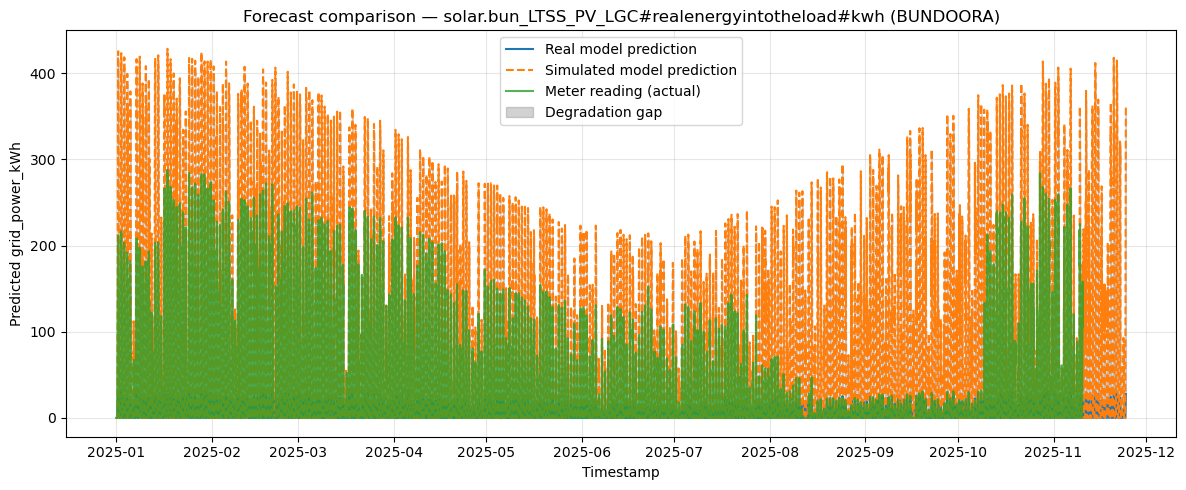

0.9703725093562656
Index(['timestamp', 'meter_reading', 'meter', 'campus', 'grid_power_kWh'], dtype='object')
act
                timestamp  meter_reading  \
28022 2025-01-01 01:00:00         0.0000   
28023 2025-01-01 02:00:00         0.0000   
28024 2025-01-01 03:00:00         0.0000   
28025 2025-01-01 04:00:00         0.0000   
28026 2025-01-01 05:00:00         0.0000   
28027 2025-01-01 06:00:00        27.6250   
28028 2025-01-01 07:00:00       169.1875   
28029 2025-01-01 08:00:00       458.7500   
28030 2025-01-01 09:00:00       636.3750   
28031 2025-01-01 10:00:00      1137.2500   

                                                 meter    campus  \
28022  solar.bun_hv_incoming#realenergyintotheload#kwh  BUNDOORA   
28023  solar.bun_hv_incoming#realenergyintotheload#kwh  BUNDOORA   
28024  solar.bun_hv_incoming#realenergyintotheload#kwh  BUNDOORA   
28025  solar.bun_hv_incoming#realenergyintotheload#kwh  BUNDOORA   
28026  solar.bun_hv_incoming#realenergyintotheload#kwh  BUNDO

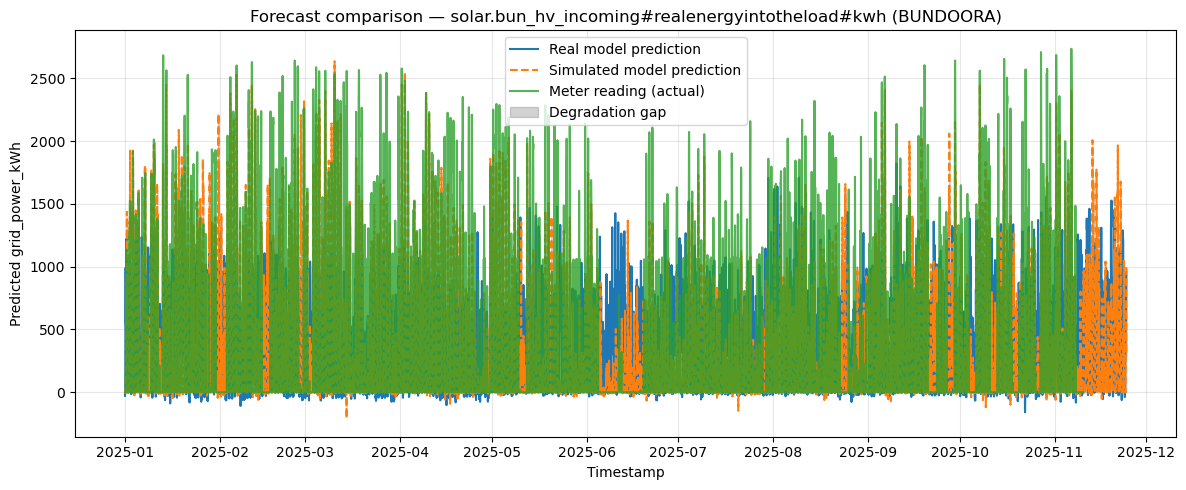

0.9703725093562656
Index(['timestamp', 'meter_reading', 'meter', 'campus', 'grid_power_kWh'], dtype='object')
act
                timestamp  meter_reading  \
45795 2025-01-01 01:00:00          0.012   
45796 2025-01-01 02:00:00          0.013   
45797 2025-01-01 03:00:00          0.011   
45798 2025-01-01 04:00:00          0.009   
45799 2025-01-01 05:00:00          0.008   
45800 2025-01-01 06:00:00          2.379   
45801 2025-01-01 07:00:00         14.509   
45802 2025-01-01 08:00:00         66.086   
45803 2025-01-01 09:00:00        166.526   
45804 2025-01-01 10:00:00        264.751   

                                             meter   campus  grid_power_kWh  
45795  solar.ben_carpark#realenergyintotheload#kwh  BENDIGO           0.012  
45796  solar.ben_carpark#realenergyintotheload#kwh  BENDIGO           0.013  
45797  solar.ben_carpark#realenergyintotheload#kwh  BENDIGO           0.011  
45798  solar.ben_carpark#realenergyintotheload#kwh  BENDIGO           0.009  
45799  sola

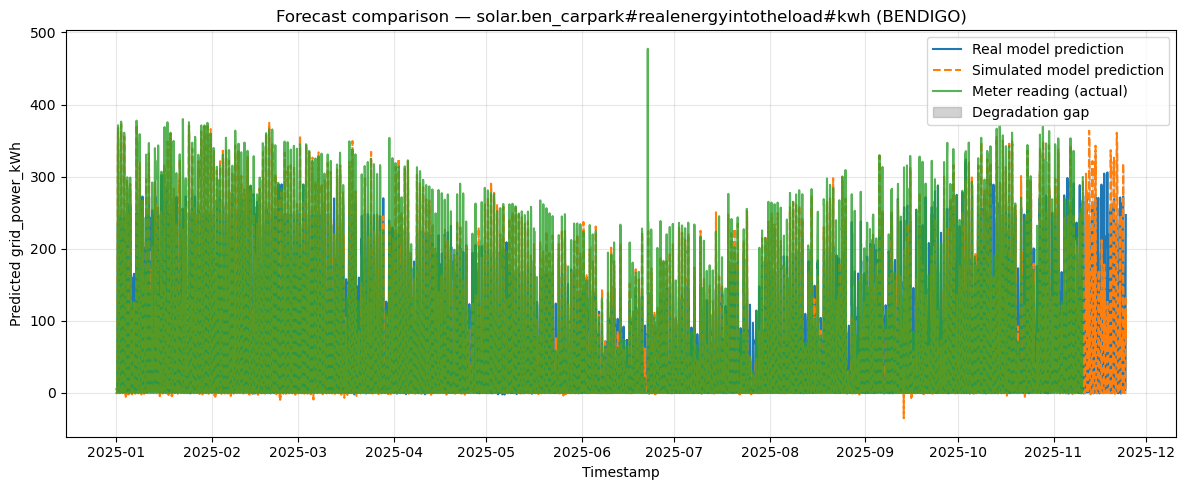

In [54]:
# common = ['solar.bun_bg#realenergyintotheload#kwh']

for meter in common:
    camp = get_campus(meter)
    if (camp in available_forecast):
        sol_df = solcast_forecast_df[solcast_forecast_df['campus'] == camp]
        features = ['global_horizontal_irradiance','air_temp','cloud_opacity','relative_humidity','dewpoint_temp','wind_speed_10m','zenith']
        target = 'grid_power_kWh'
        
        # --- minimal: normalize & dedupe forecast timestamps ---
        sol_df = sol_df.copy()
        sol_df["timestamp"] = pd.to_datetime(sol_df["timestamp"], errors="coerce")
        sol_df = sol_df.dropna(subset=["timestamp"]).sort_values("timestamp")
        sol_df = sol_df.drop_duplicates(subset=["timestamp"], keep="first")
        sol_df = sol_df[sol_df["timestamp"].dt.minute == 0]
        X = sol_df[features].astype(float)

        xg_model_real = joblib.load('models/real_h/' + meter + '.pkl')
        xg_model_simulated = joblib.load('models/simulated/' + meter + '.pkl')

        y_real = xg_model_real.predict(X)
        y_sim  = xg_model_simulated.predict(X)

        # ----------------- Degradation -----------------
        DEGRADE_RATE_PER_YEAR = 0.005
        FIRST_YEAR_DROP = 0.00
        t_idx = sol_df["timestamp"]
        years_since_start = 6
        deg_factor = (1.0 - FIRST_YEAR_DROP) * np.power((1.0 - DEGRADE_RATE_PER_YEAR), years_since_start)
        y_sim_degraded = np.clip(y_sim * deg_factor, 0.0, None)
        print(deg_factor)
        print(final_df.keys())
        # print(final_df.head(10))
        # ----------------- Actuals slice -----------------
        act = final_df[final_df["meter"] == meter].copy()
        act["timestamp"] = pd.to_datetime(act["timestamp"], errors="coerce")
        act = act.dropna(subset=["timestamp"]).sort_values("timestamp")
        act = act[act["timestamp"] >= sol_df["timestamp"].iloc[0]]
        # minimal: drop dup timestamps in actuals
        act = act.drop_duplicates(subset=["timestamp"], keep="first")

        # ----------------- Build Series (make indexes unique) -----------------
        def make_unique_series(values, index, keep="first"):
            s = pd.Series(values, index=index)
            if keep == "first":
                s = s[~s.index.duplicated(keep="first")]
            else:
                s = s.groupby(level=0).mean()
            return s.sort_index()

        print("act")
        print(act.head(10))
        s_act     = make_unique_series(act["grid_power_kWh"].values, act["timestamp"], keep="first")
        s_real    = make_unique_series(y_real,            sol_df["timestamp"], keep="first")
        s_sim     = make_unique_series(y_sim,             sol_df["timestamp"], keep="first")
        s_sim_deg = make_unique_series(y_sim_degraded,    sol_df["timestamp"], keep="first")
        s_ghi     = make_unique_series(sol_df["global_horizontal_irradiance"].values,
                                       sol_df["timestamp"]).astype(float)

        # ------------------ SAVE TO CSV ------------------
        all_idx = s_act.index.union(s_real.index).union(s_sim.index).union(s_sim_deg.index)

        df_out = pd.DataFrame(index=all_idx).sort_index()
        df_out.index.name = "timestamp"
        df_out.insert(0, "meter", meter)
        df_out.insert(1, "campus", camp)

        df_out["Meter_reading"]         = s_act.reindex(all_idx)
        df_out["Real_model_prediction"] = s_real.reindex(all_idx)
        df_out["Simulated_model"]       = s_sim.reindex(all_idx)
        df_out["Simulated_degraded"]    = s_sim_deg.reindex(all_idx)
        df_out["global_horizontal_irradiance"] = s_ghi.reindex(all_idx)

        print(df_out.head(10))

        csv_filename = f"{meter}_series_new.csv".replace("/", "-")
        df_out.to_csv(os.path.join("Results", csv_filename))

        # ------------------ Plot ------------------
        plt.figure(figsize=(12, 5))
        plt.plot(s_real.index, s_real.values, label="Real model prediction")
        plt.plot(s_sim.index,  s_sim.values,  label="Simulated model prediction", linestyle="--")
        plt.plot(s_act.index,  s_act.values,  label="Meter reading (actual)", linewidth=1.5, alpha=0.8)
        plt.fill_between(s_sim_deg.index, 0, s_sim_deg.values,
                         color="gray", alpha=0.35, label="Degradation gap", zorder=1)

        plt.title(f"Forecast comparison — {meter} ({camp})")
        plt.xlabel("Timestamp")
        plt.ylabel("Predicted grid_power_kWh")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


          timestamp  meter_reading                                     meter
2021-01-01 00:00:00       0.000000 solar.bun_carm1#realenergyintotheload#kwh
2021-01-01 00:30:00       0.000000 solar.bun_carm1#realenergyintotheload#kwh
2021-01-01 01:00:00       0.000000 solar.bun_carm1#realenergyintotheload#kwh
2021-01-01 01:30:00       0.000000 solar.bun_carm1#realenergyintotheload#kwh
2021-01-01 02:00:00       0.000000 solar.bun_carm1#realenergyintotheload#kwh
2021-01-01 02:30:00       0.000000 solar.bun_carm1#realenergyintotheload#kwh
2021-01-01 03:00:00       0.000000 solar.bun_carm1#realenergyintotheload#kwh
2021-01-01 03:30:00       0.000000 solar.bun_carm1#realenergyintotheload#kwh
2021-01-01 04:00:00       0.000000 solar.bun_carm1#realenergyintotheload#kwh
2021-01-01 04:30:00       0.000000 solar.bun_carm1#realenergyintotheload#kwh
2021-01-01 05:00:00       0.000000 solar.bun_carm1#realenergyintotheload#kwh
2021-01-01 05:30:00       0.000000 solar.bun_carm1#realenergyintotheload#kwh

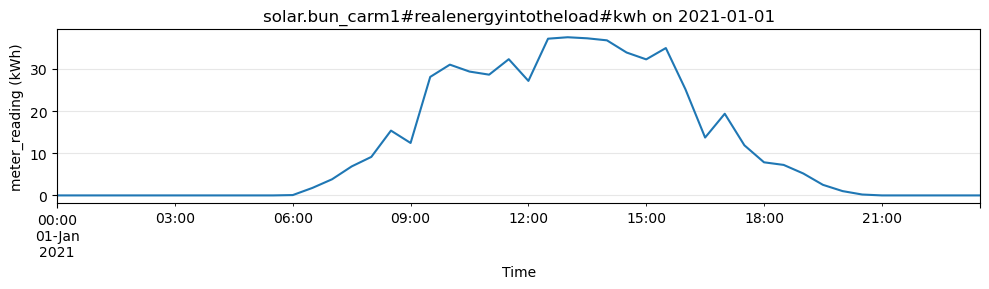

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Load CSV ---
# Change the path if needed
df = pd.read_csv("data\SolarMeterReadings30min.csv", parse_dates=["timestamp"])

# --- Params ---
meter_key = "solar.bun_carm1#realenergyintotheload#kwh"     # case-insensitive partial match
day_str   = "2021-01-01"        # the day you want

# --- Filter to this meter ---
m_mask = df["meter"].str.lower().str.contains(meter_key.lower(), regex=False)

# --- Filter to that single day (00:00 to <00:00 next day) ---
d0 = pd.to_datetime(day_str)
d1 = d0 + pd.Timedelta(days=1)
day_df = (
    df.loc[m_mask & (df["timestamp"] >= d0) & (df["timestamp"] < d1),
           ["timestamp", "meter_reading", "meter"]]
    .sort_values("timestamp")
)

# --- See the data ---
print(day_df.to_string(index=False))

# --- Optional: quick plot ---
if not day_df.empty:
    ax = day_df.set_index("timestamp")["meter_reading"].plot(figsize=(10, 3))
    ax.set_title(f"{meter_key} on {d0.date()}")
    ax.set_xlabel("Time")
    ax.set_ylabel("meter_reading (kWh)")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    # Helpful hint if nothing found
    avail = df.loc[m_mask, "timestamp"]
    if not avail.empty:
        print(f"No records on {d0.date()}. Available range for this meter: "
              f"{avail.min().date()} to {avail.max().date()}")
    else:
        print("No rows matching this meter id.")
